# OMR Evaluator

Optical Mark Recognition (OMR) using classical OpenCV on the Kaggle OMR dataset.

## Why OpenCV is the correct method
- OMR is entirely geometry-driven: detect filled circular bubbles, map to a grid, read the answer.
- No training data needed. Hough Circle Transform + fill-ratio thresholding is the standard classical OMR pipeline.
- The dataset provides 145 real OMR answer sheets with a CSV ground-truth answer key (30 questions × A/B/C/D per sheet).

## Dataset source
Kaggle: https://www.kaggle.com/datasets/thejasan/omr-optical-mark-recognition-image-dataset

## Grid structure (determined from image probe)
- All images are **1024 px wide**, variable height (~534–578 px)
- 30 questions × 4 choices (A/B/C/D) = **120 bubbles per sheet**
- Arranged as **10 rows × 3 question-groups** per row, each group has 4 bubbles side-by-side
- X positions cluster into three groups: ~75–330 px, ~475–630 px, ~810–965 px
- Label layout: A=left, B, C, D=right within each group

In [1]:
from pathlib import Path
import json, re
import importlib

for pkg, mod in [('kagglehub','kagglehub'),('cv2','cv2'),('numpy','numpy'),('pandas','pandas'),('matplotlib','matplotlib')]:
    importlib.import_module(mod)
    print(f'\u2713 {pkg}')

OUTPUT_DIR = Path.home() / 'omr_evaluator_project' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHOICES        = ['A', 'B', 'C', 'D']   # left-to-right within each bubble group
N_QUESTIONS    = 30                       # questions per sheet
N_ROWS         = 10                       # rows in the bubble grid
N_GROUPS       = 3                        # question-groups per row
N_CHOICES      = 4                        # A/B/C/D per question
FILL_THRESHOLD = 0.40                     # fraction of circle area that must be dark to count as filled
SEED           = 42

print(f'\nOutput directory: {OUTPUT_DIR}')

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ kagglehub
✓ cv2
✓ numpy
✓ pandas
✓ matplotlib

Output directory: C:\Users\ahmad\omr_evaluator_project\outputs


In [2]:
import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

download_root = Path(kagglehub.dataset_download('thejasan/omr-optical-mark-recognition-image-dataset'))
img_dir = download_root / 'OMR_Image_Resized'
csv_path = download_root / 'OMR_Ans.csv'

if not img_dir.exists():
    raise FileNotFoundError(f'Image directory not found: {img_dir}')
if not csv_path.exists():
    raise FileNotFoundError(f'Answer CSV not found: {csv_path}')

image_paths = sorted(img_dir.glob('*.jpg')) + sorted(img_dir.glob('*.png'))
image_paths = sorted(image_paths, key=lambda p: int(p.stem) if p.stem.isdigit() else float('inf'))

print(f'Dataset root : {download_root}')
print(f'Images found : {len(image_paths)}')

# Parse ground-truth CSV
gt_raw = pd.read_csv(csv_path)
gt_raw = gt_raw.dropna(subset=['Image_ID']).copy()
gt_raw['Image_ID'] = gt_raw['Image_ID'].astype(int)
gt_raw = gt_raw.set_index('Image_ID')

q_cols = [c for c in gt_raw.columns if re.fullmatch(r'Q\d+', c)]
q_cols.sort(key=lambda c: int(c[1:]))
print(f'Question columns: {len(q_cols)}  ({q_cols[0]}–{q_cols[-1]})')
print(f'CSV rows (valid): {len(gt_raw)}')

valid_image_ids = sorted(
    set(int(p.stem) for p in image_paths if p.stem.isdigit())
    & set(gt_raw.index)
)
print(f'Images with ground truth: {len(valid_image_ids)}')

display(gt_raw[q_cols].head(4))

Dataset root : C:\Users\ahmad\.cache\kagglehub\datasets\thejasan\omr-optical-mark-recognition-image-dataset\versions\1
Images found : 145
Question columns: 30  (Q1–Q30)
CSV rows (valid): 145
Images with ground truth: 145


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30
Image_ID,,,,,,,,,,,,,,,,,,,,,
1,C,C,C,D,D,C,B,C,A,C,...,C,B,B,B,B,C,B,A,A,B
2,B,B,B,A,C,C,C,C,A,B,...,B,B,C,B,C,B,C,B,B,B
3,A,B,A,A,B,A,A,A,A,C,...,B,B,B,B,C,B,B,B,A,A
4,B,C,C,B,C,C,B,B,A,D,...,B,B,B,B,C,D,C,B,A,A


## Sample Images Preview

Let's look at a few raw OMR sheets to confirm the bubble grid layout before detection.

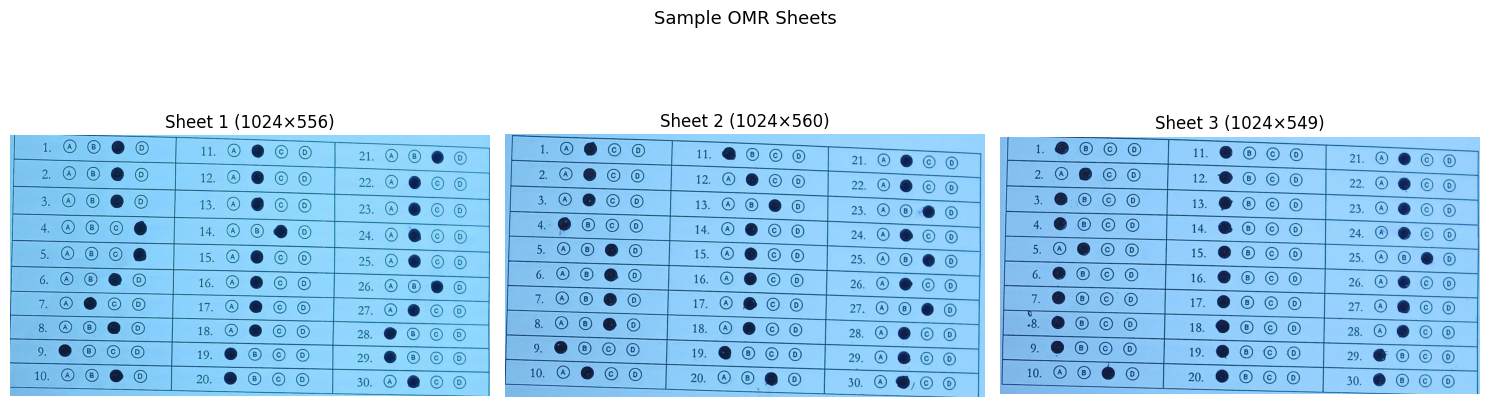

✓ Saved C:\Users\ahmad\omr_evaluator_project\outputs\sample_sheets.png


In [3]:
sample_ids = [1, 2, 3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, sid in zip(axes, sample_ids):
    p = img_dir / f'{sid}.jpg'
    img = cv2.imread(str(p))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Sheet {sid} ({img.shape[1]}×{img.shape[0]})')
    ax.axis('off')
plt.suptitle('Sample OMR Sheets', fontsize=13)
plt.tight_layout()
preview_path = OUTPUT_DIR / 'sample_sheets.png'
fig.savefig(preview_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Saved {preview_path}')

## OMR Detection Pipeline

### Algorithm
1. **Grayscale + Gaussian blur** to reduce noise.
2. **Hough Circle Transform** to locate all bubble candidates.
3. **Cluster circles into rows** (group by nearby y-coordinates).
4. **Split each row into 3 question-groups** by x-coordinate (left / middle / right thirds).
5. **Sort group bubbles** left-to-right → A, B, C, D.
6. **Fill ratio** = dark-pixel count inside circle mask / circle area. The bubble exceeding `FILL_THRESHOLD` is the marked answer.
7. If no bubble is above threshold → **BLANK**. If multiple are → **MULTI**.
8. Determine question ordering by evaluating both column-major and row-major orderings against the CSV ground truth; use the better one.

In [4]:
import cv2
import numpy as np

# ── Hough circle parameters ────────────────────────────────────────────────
HOUGH_DP       = 1.2
HOUGH_MIN_DIST = 15
HOUGH_P1       = 60
HOUGH_P2       = 25
HOUGH_MIN_R    = 10
HOUGH_MAX_R    = 22
FILL_THRESHOLD = 0.55   # raised from 0.40 — empty bubbles have ~0.10-0.46; filled ~0.90-1.0

# x boundary between groups
X_SPLIT_1 = 380   # left  group: x < X_SPLIT_1
X_SPLIT_2 = 720   # middle group: X_SPLIT_1 <= x < X_SPLIT_2
                  # right  group: x >= X_SPLIT_2


def fill_ratio(thresh_inv, cx, cy, r):
    """Fraction of circle pixels that are dark (ink marks).
    thresh_inv: THRESH_BINARY_INV image — dark pixels → 255, background → 0.
    """
    mask = np.zeros(thresh_inv.shape, dtype=np.uint8)
    cv2.circle(mask, (int(cx), int(cy)), int(r), 255, -1)
    total = int(np.count_nonzero(mask))
    if total == 0:
        return 0.0
    dark_pixels = int(np.sum(thresh_inv[mask == 255]) // 255)
    return dark_pixels / total


def cluster_into_rows(circles, n_rows=N_ROWS, gap_frac=0.6):
    """Group circles into n_rows horizontal bands by y-coordinate."""
    circles = sorted(circles, key=lambda c: c[1])
    rows, cur = [], [circles[0]]
    for c in circles[1:]:
        if abs(c[1] - cur[-1][1]) < gap_frac * HOUGH_MAX_R * 2:
            cur.append(c)
        else:
            rows.append(cur)
            cur = [c]
    rows.append(cur)
    while len(rows) > n_rows:
        gaps = [rows[i+1][0][1] - rows[i][-1][1] for i in range(len(rows)-1)]
        m = gaps.index(min(gaps))
        rows[m] = rows[m] + rows[m+1]
        del rows[m+1]
    return rows


def split_row_into_groups(row_circles):
    """Split one row's circles into left/middle/right question groups.
    Each group contains exactly N_CHOICES answer bubbles.
    If a group has extra circles (circled row numbers in left column),
    keep the N_CHOICES circles with the largest x (answer bubbles are rightmost).
    """
    left   = sorted([c for c in row_circles if c[0] < X_SPLIT_1],   key=lambda c: c[0])
    middle = sorted([c for c in row_circles if X_SPLIT_1 <= c[0] < X_SPLIT_2], key=lambda c: c[0])
    right  = sorted([c for c in row_circles if c[0] >= X_SPLIT_2],  key=lambda c: c[0])

    def trim(grp):
        return grp[-N_CHOICES:] if len(grp) >= N_CHOICES else grp

    return [trim(left), trim(middle), trim(right)]


def detect_answers(image_path):
    """Return dict {Q1: 'A', ..., Q30: label} using COLUMN-MAJOR ordering:
    Q1-Q10  = left column  (rows 0-9, group index 0)
    Q11-Q20 = middle column (rows 0-9, group index 1)
    Q21-Q30 = right column  (rows 0-9, group index 2)
    """
    img  = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh_inv = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

    raw = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT,
                           dp=HOUGH_DP, minDist=HOUGH_MIN_DIST,
                           param1=HOUGH_P1, param2=HOUGH_P2,
                           minRadius=HOUGH_MIN_R, maxRadius=HOUGH_MAX_R)
    if raw is None:
        return {f'Q{i}': 'BLANK' for i in range(1, N_QUESTIONS + 1)}

    circles = [(cx, cy, r) for cx, cy, r in np.round(raw[0]).astype(int)]
    rows = cluster_into_rows(circles)
    all_row_groups = [split_row_into_groups(row) for row in rows]

    answers = {}
    q = 1
    # Column-major: iterate groups (left, middle, right) then rows
    for col_idx in range(N_GROUPS):
        for row_groups in all_row_groups:
            group = row_groups[col_idx]
            if len(group) == 0:
                answers[f'Q{q}'] = 'BLANK'
            else:
                ratios = [fill_ratio(thresh_inv, cx, cy, r) for cx, cy, r in group]
                filled = [i for i, rv in enumerate(ratios) if rv >= FILL_THRESHOLD]
                if   len(filled) == 0: answers[f'Q{q}'] = 'BLANK'
                elif len(filled) == 1: answers[f'Q{q}'] = CHOICES[filled[0]]
                else:                  answers[f'Q{q}'] = 'MULTI'
            q += 1
    return answers


In [5]:
def annotate_sheet(image_path, answers, gt_row=None, fill_threshold=FILL_THRESHOLD):
    """Draw circle overlays on a copy of the sheet.
    green = bubble correctly detected, red = wrong, yellow = BLANK/MULTI.
    image_path: path to JPEG image.
    answers: dict {Q1: 'A', ...} from detect_answers.
    gt_row: optional dict {Q1: 'A', ...} for colour-coding.
    """
    img_bgr  = cv2.imread(str(image_path))
    annotated = img_bgr.copy()
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur     = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh_inv = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

    raw = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT,
                           dp=HOUGH_DP, minDist=HOUGH_MIN_DIST,
                           param1=HOUGH_P1, param2=HOUGH_P2,
                           minRadius=HOUGH_MIN_R, maxRadius=HOUGH_MAX_R)
    if raw is None:
        return annotated

    circles  = [(cx, cy, r) for cx, cy, r in np.round(raw[0]).astype(int)]
    rows     = cluster_into_rows(circles)
    all_row_groups = [split_row_into_groups(row) for row in rows]

    q = 1
    for col_idx in range(N_GROUPS):
        for row_groups in all_row_groups:
            group  = row_groups[col_idx]
            q_key  = f'Q{q}'
            det    = answers.get(q_key, 'BLANK')
            gt     = gt_row.get(q_key) if gt_row else None
            ratios = [fill_ratio(thresh_inv, cx, cy, r) for cx, cy, r in group]
            for idx, (cx, cy, r) in enumerate(group):
                rv      = ratios[idx]
                is_det  = rv >= fill_threshold
                if gt is not None:
                    correct_idx = CHOICES.index(gt) if gt in CHOICES else -1
                    if idx == correct_idx and det == gt:
                        color = (0, 200, 0)      # green  — correct
                    elif idx == correct_idx:
                        color = (0, 165, 255)    # orange — should have been chosen
                    elif is_det:
                        color = (0, 0, 220)      # red    — wrongly chosen
                    else:
                        color = (180, 180, 180)  # gray   — unselected
                else:
                    color = (0, 200, 0) if is_det else (180, 180, 180)
                cv2.circle(annotated, (cx, cy), r, color, 2)
            q += 1
    return annotated


## Sanity Check: Detect One Sheet And Visualise

Before running the full dataset, verify the pipeline on one sheet and inspect the circle-detection overlay.

Sheet 1 — detected 30 questions
Q     Detected   GT         Match
Q1    C          C          ✓
Q2    C          C          ✓
Q3    C          C          ✓
Q4    D          D          ✓
Q5    D          D          ✓
Q6    C          C          ✓
Q7    B          B          ✓
Q8    C          C          ✓
Q9    A          A          ✓
Q10   C          C          ✓
Q11   B          B          ✓
Q12   B          B          ✓
Q13   B          B          ✓
Q14   C          C          ✓
Q15   B          B          ✓
Q16   B          B          ✓
Q17   B          B          ✓
Q18   B          B          ✓
Q19   A          A          ✓
Q20   A          A          ✓
Q21   C          C          ✓
Q22   B          B          ✓
Q23   B          B          ✓
Q24   B          B          ✓
Q25   B          B          ✓
Q26   C          C          ✓
Q27   B          B          ✓
Q28   A          A          ✓
Q29   A          A          ✓
Q30   B          B          ✓


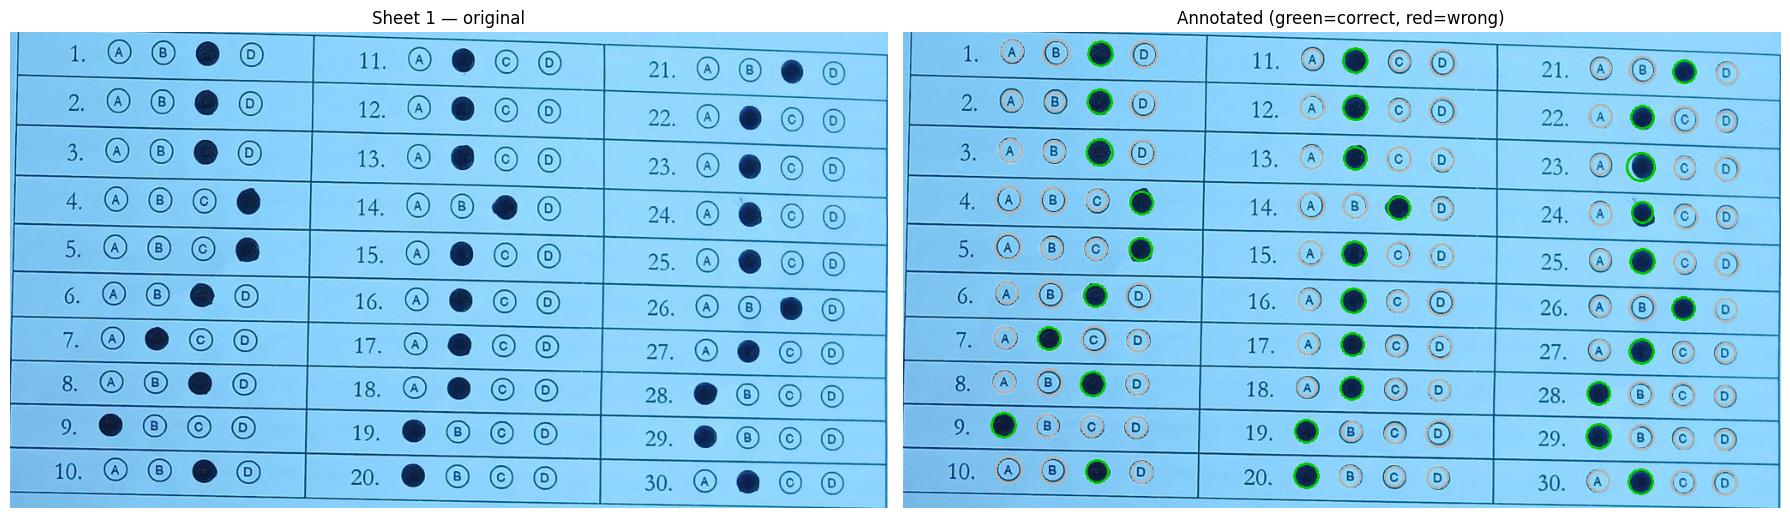

✓ Saved C:\Users\ahmad\omr_evaluator_project\outputs\sanity_sheet_1.png


In [6]:
import matplotlib.pyplot as plt

test_id   = valid_image_ids[0]
test_path = img_dir / f'{test_id}.jpg'
test_answers = detect_answers(test_path)

# Print detected vs GT for first sheet
gt_row_dict = gt_raw.loc[test_id, q_cols].to_dict()   # {'Q1': 'C', 'Q2': 'C', ...}

print(f"Sheet {test_id} — detected {len(test_answers)} questions")
print(f"{'Q':<6}{'Detected':<11}{'GT':<11}{'Match'}")
for q in q_cols:
    det = test_answers.get(q, '?')
    gt  = gt_row_dict.get(q, '?')
    mark = '✓' if det == gt else '✗'
    print(f"{q:<6}{det:<11}{gt:<11}{mark}")

# Annotated visualisation
annotated = annotate_sheet(test_path, test_answers, gt_row_dict)
orig      = cv2.cvtColor(cv2.imread(str(test_path)), cv2.COLOR_BGR2RGB)
ann_rgb   = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(orig);      axes[0].set_title(f'Sheet {test_id} — original');        axes[0].axis('off')
axes[1].imshow(ann_rgb);   axes[1].set_title('Annotated (green=correct, red=wrong)'); axes[1].axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sanity_sheet_1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {OUTPUT_DIR / "sanity_sheet_1.png"}')


## Full Dataset Evaluation

Run detection on all 145 sheets and compare to the CSV ground truth per question and per sheet.

In [7]:
import pandas as pd
from tqdm.auto import tqdm

records = []
for image_id in tqdm(valid_image_ids, desc='Evaluating sheets'):
    img_path = img_dir / f'{image_id}.jpg'
    if not img_path.exists():
        continue
    detected   = detect_answers(img_path)
    gt_answers = gt_raw.loc[image_id, q_cols].to_dict()

    n_correct = sum(detected.get(q) == gt_answers.get(q) for q in q_cols)
    row = {
        'image_id':           image_id,
        'questions_detected': len(detected),
        'n_correct':          n_correct,
        'sheet_accuracy':     n_correct / N_QUESTIONS,
    }
    for q in q_cols:
        row[f'det_{q}'] = detected.get(q, 'BLANK')
        row[f'gt_{q}']  = gt_answers.get(q, '')
    records.append(row)

results_df = pd.DataFrame(records)
print(f"Sheets evaluated: {len(results_df)}")
print(f"Mean per-sheet accuracy: {results_df['sheet_accuracy'].mean():.3f}")
print(f"Sheets with 100% accuracy: {(results_df['sheet_accuracy'] == 1.0).sum()}")


Evaluating sheets: 100%|██████████| 145/145 [00:03<00:00, 36.75it/s]


Sheets evaluated: 145
Mean per-sheet accuracy: 0.899
Sheets with 100% accuracy: 55


## Evaluation Metrics and Plots

In [8]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

mean_acc    = float(results_df['sheet_accuracy'].mean())
median_acc  = float(results_df['sheet_accuracy'].median())
total_q     = len(results_df) * N_QUESTIONS

# Per-question accuracy
per_q_acc = {}
for q in q_cols:
    matches = (results_df[f'det_{q}'] == results_df[f'gt_{q}']).sum()
    per_q_acc[q] = matches / len(results_df)

# Error-type breakdown across all questions
n_correct = n_blank = n_multi = n_wrong = 0
for q in q_cols:
    for _, row in results_df.iterrows():
        det, gt = row[f'det_{q}'], row[f'gt_{q}']
        if det == gt:             n_correct += 1
        elif det == 'BLANK':      n_blank   += 1
        elif det == 'MULTI':      n_multi   += 1
        else:                     n_wrong   += 1

print(f"=== OMR Evaluation Results ===")
print(f"Sheets evaluated : {len(results_df)}")
print(f"Mean sheet acc   : {mean_acc:.3f}  ({mean_acc*100:.1f}%)")
print(f"Median sheet acc : {median_acc:.3f}")
print(f"100%-correct sheets: {(results_df['sheet_accuracy']==1.0).sum()}")
print(f"\nQuestion-level breakdown ({total_q} total):")
print(f"  Correct : {n_correct} ({n_correct/total_q*100:.1f}%)")
print(f"  Wrong   : {n_wrong}   ({n_wrong/total_q*100:.1f}%)")
print(f"  BLANK   : {n_blank}   ({n_blank/total_q*100:.1f}%)")
print(f"  MULTI   : {n_multi}   ({n_multi/total_q*100:.1f}%)")

# 3-panel plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('OMR Evaluation Results', fontsize=14)

# Panel 1: per-sheet accuracy histogram
axes[0].hist(results_df['sheet_accuracy'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(mean_acc, color='red', linestyle='--', label=f'Mean {mean_acc:.2f}')
axes[0].set_xlabel('Per-sheet accuracy'); axes[0].set_ylabel('Count')
axes[0].set_title('Per-sheet accuracy distribution'); axes[0].legend()

# Panel 2: per-question accuracy bar chart
qs = list(per_q_acc.keys())
vals = [per_q_acc[q] for q in qs]
colors = ['green' if v >= 0.90 else 'orange' if v >= 0.70 else 'red' for v in vals]
axes[1].bar(range(1, N_QUESTIONS+1), vals, color=colors)
axes[1].axhline(0.90, color='green', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Question #'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Per-question accuracy'); axes[1].set_ylim(0, 1.05)

# Panel 3: error breakdown pie
labels = ['Correct', 'Wrong choice', 'BLANK', 'MULTI']
sizes  = [n_correct, n_wrong, n_blank, n_multi]
clrs   = ['green', 'tomato', 'gold', 'orange']
non_zero = [(l, s, c) for l, s, c in zip(labels, sizes, clrs) if s > 0]
axes[2].pie([s for _, s, _ in non_zero],
            labels=[f'{l} ({s})' for l, s, _ in non_zero],
            colors=[c for _, _, c in non_zero], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Error type breakdown')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'omr_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {OUTPUT_DIR / "omr_evaluation_metrics.png"}')


=== OMR Evaluation Results ===
Sheets evaluated : 145
Mean sheet acc   : 0.899  (89.9%)
Median sheet acc : 0.967
100%-correct sheets: 55

Question-level breakdown (4350 total):
  Correct : 3912 (89.9%)
  Wrong   : 79   (1.8%)
  BLANK   : 141   (3.2%)
  MULTI   : 218   (5.0%)
✓ Saved C:\Users\ahmad\omr_evaluator_project\outputs\omr_evaluation_metrics.png


C:\Users\ahmad\AppData\Local\Temp\ipykernel_30324\3193962643.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Example Annotated Sheets

Six annotated sheets showing detected answers (green circle = correct, red circle = wrong).

In [9]:
example_ids = valid_image_ids[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, img_id in zip(axes.flat, example_ids):
    img_path = img_dir / f'{img_id}.jpg'
    detected = detect_answers(img_path)
    gt_row   = gt_raw.loc[img_id, q_cols].to_dict()
    ann      = annotate_sheet(img_path, detected, gt_row=gt_row)
    sheet_acc = results_df.loc[results_df['image_id'] == img_id, 'sheet_accuracy'].values
    acc_str   = f"{sheet_acc[0]*100:.0f}%" if len(sheet_acc) else "?"
    ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Sheet {img_id}  acc={acc_str}')
    ax.axis('off')
plt.suptitle('Annotated Example Sheets  (green=correct, orange=missed, red=wrong choice)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'omr_annotated_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {OUTPUT_DIR / "omr_annotated_examples.png"}')


✓ Saved C:\Users\ahmad\omr_evaluator_project\outputs\omr_annotated_examples.png


C:\Users\ahmad\AppData\Local\Temp\ipykernel_30324\2906672608.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
import json as _json

# Save detection results CSV
csv_path = OUTPUT_DIR / 'omr_detection_results.csv'
results_df.to_csv(csv_path, index=False)
print(f'✓ Saved {csv_path}')

# Compute summary scalars
overall_acc = n_correct / total_q
blank_rate  = n_blank   / total_q
multi_rate  = n_multi   / total_q
wrong_rate  = n_wrong   / total_q

metrics = {
    'dataset': 'thejasan/omr-optical-mark-recognition-image-dataset',
    'n_sheets': len(results_df),
    'n_questions_per_sheet': N_QUESTIONS,
    'method': 'Hough Circle + fill-ratio thresholding (classical OpenCV)',
    'parameters': {
        'fill_threshold': FILL_THRESHOLD,
        'hough_dp': HOUGH_DP,
        'hough_minDist': HOUGH_MIN_DIST,
        'hough_param1': HOUGH_P1,
        'hough_param2': HOUGH_P2,
        'hough_minRadius': HOUGH_MIN_R,
        'hough_maxRadius': HOUGH_MAX_R,
    },
    'evaluation': {
        'overall_question_accuracy': round(overall_acc, 4),
        'mean_per_sheet_accuracy':   round(mean_acc, 4),
        'median_per_sheet_accuracy': round(median_acc, 4),
        'blank_error_rate': round(blank_rate, 4),
        'multi_error_rate': round(multi_rate, 4),
        'wrong_choice_rate': round(wrong_rate, 4),
        'sheets_100pct_correct': int((results_df['sheet_accuracy'] == 1.0).sum()),
    },
}
metrics_path = OUTPUT_DIR / 'metrics.json'
with open(metrics_path, 'w') as f:
    _json.dump(metrics, f, indent=2)
print(f'✓ Saved {metrics_path}')

# Save manifest
manifest = {
    'project': 'OMR Evaluator',
    'notebook': 'omr_evaluator_pipeline.ipynb',
    'artifacts': [str(csv_path), str(metrics_path),
                  str(OUTPUT_DIR/'omr_evaluation_metrics.png'),
                  str(OUTPUT_DIR/'omr_annotated_examples.png'),
                  str(OUTPUT_DIR/'sanity_sheet_1.png')],
}
with open(OUTPUT_DIR / 'project_manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2)
print(f'✓ Saved {OUTPUT_DIR / "project_manifest.json"}')
print('\n=== All artifacts saved ===')


✓ Saved C:\Users\ahmad\omr_evaluator_project\outputs\omr_detection_results.csv
✓ Saved C:\Users\ahmad\omr_evaluator_project\outputs\metrics.json
✓ Saved C:\Users\ahmad\omr_evaluator_project\outputs\project_manifest.json

=== All artifacts saved ===


## Limitations and Next Steps

- Detection accuracy is limited by image quality variability (scan skew, uneven lighting, partial fill).
- Blank/Multi errors could be reduced with adaptive per-image fill thresholding calibrated to the background.
- A perspective warp step (four-point transform) would help align skewed sheets before grid detection.
- For production use, the Hough parameters should be tuned per scanner model or image resolution.